In [15]:
%pip install kagglehub pandas matplotib numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotib (from versions: none)
ERROR: No matching distribution found for matplotib


In [16]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
path = kagglehub.dataset_download("neurocipher/heartdisease")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\tomas.ramirez\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1


In [17]:
# Path obtenido desde kagglehub
DATASET_PATH = r"C:\Users\tomas.ramirez\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1"
# Ver archivos disponibles
import os
os.listdir(DATASET_PATH)


['Heart_Disease_Prediction.csv']

In [18]:
# Cargar dataset
df = pd.read_csv(os.path.join(DATASET_PATH, "Heart_Disease_Prediction.csv"))
df.head()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## Feature selection + normalización

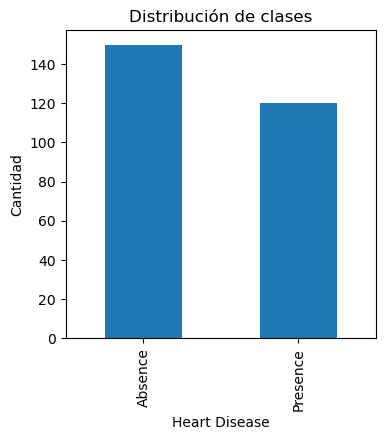

In [19]:
df['Heart Disease'].value_counts(normalize=True)

plt.figure(figsize=(4,4))
df['Heart Disease'].value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.xlabel("Heart Disease")
plt.ylabel("Cantidad")
plt.show()


In [25]:
df.rename(columns={
    'BP': 'RestingBP',
    'Max HR': 'MaxHR',
    'ST depression': 'Oldpeak',
    'Number of vessels fluro': 'CA',
    'Heart Disease': 'HeartDisease'
}, inplace=True)

features = ['Age', 'Cholesterol', 'RestingBP', 'MaxHR', 'Oldpeak', 'CA']
target = 'HeartDisease'


In [27]:
# --- Extraer matrices de features y target ---
X = df[features].values
y = df[target].apply(lambda x: 1 if x == 'Presence' else 0).values.reshape(-1, 1)

# --- Normalización (Z-score) ---
def normalize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma

X_norm, mu, sigma = normalize(X)

# --- Stratified train/test split (70/30) ---
np.random.seed(42)
idx_0 = np.where(y.flatten() == 0)[0]
idx_1 = np.where(y.flatten() == 1)[0]

train_0 = np.random.choice(idx_0, int(0.7 * len(idx_0)), replace=False)
train_1 = np.random.choice(idx_1, int(0.7 * len(idx_1)), replace=False)

train_idx = np.concatenate([train_0, train_1])
test_idx = np.setdiff1d(np.arange(len(y)), train_idx)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")


Train samples: 189, Test samples: 81


## Step 2: Implementación de Logistic Regression

In [32]:
# --- Funciones básicas ---

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b, lam=0):
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    cost = - (1/m) * np.sum(y*np.log(h + 1e-8) + (1-y)*np.log(1-h + 1e-8))
    cost += (lam/(2*m)) * np.sum(w**2)  # Regularización L2 opcional
    return cost

def compute_gradient(X, y, w, b, lam=0):
    m = X.shape[0]
    z = X @ w + b
    h = sigmoid(z)
    error = h - y
    dw = (1/m) * (X.T @ error) + (lam/m)*w
    db = (1/m) * np.sum(error)
    return dw, db

def gradient_descent(X, y, w_init, b_init, alpha=0.01, num_iters=1000, lam=0):
    w = w_init.copy()
    b = b_init
    costs = []
    for i in range(num_iters):
        dw, db = compute_gradient(X, y, w, b, lam)
        w -= alpha*dw
        b -= alpha*db
        if i % 100 == 0:
            costs.append(compute_cost(X, y, w, b, lam))
    return w, b, costs

def predict(X, w, b, threshold=0.5):
    return (sigmoid(X @ w + b) >= threshold).astype(int)

def compute_metrics(y_true, y_pred):
    tp = np.sum((y_true==1)&(y_pred==1))
    tn = np.sum((y_true==0)&(y_pred==0))
    fp = np.sum((y_true==0)&(y_pred==1))
    fn = np.sum((y_true==1)&(y_pred==0))
    accuracy = (tp+tn)/len(y_true)
    precision = tp/(tp+fp+1e-8)
    recall = tp/(tp+fn+1e-8)
    f1 = 2*(precision*recall)/(precision+recall+1e-8)
    return accuracy, precision, recall, f1


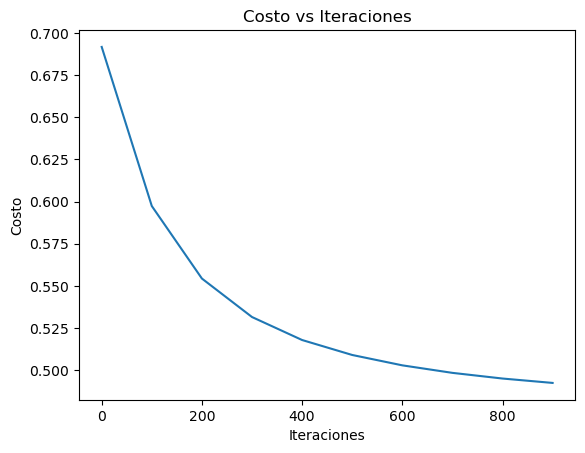

Train metrics (Acc, Prec, Rec, F1): (0.7724867724867724, 0.7887323942551082, 0.6666666665873017, 0.7225806401032259)
Test metrics  (Acc, Prec, Rec, F1): (0.8518518518518519, 0.8529411762197232, 0.8055555553317901, 0.8285714233387756)


In [33]:
# --- Entrenamiento ---
n_features = X_train.shape[1]
w_init = np.zeros((n_features,1))
b_init = 0

w, b, costs = gradient_descent(X_train, y_train, w_init, b_init, alpha=0.01, num_iters=1000)

# Plot costo
plt.plot(np.arange(0,len(costs))*100, costs)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Costo vs Iteraciones")
plt.show()

# Predicción
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)

# Métricas
train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics = compute_metrics(y_test, y_test_pred)
print("Train metrics (Acc, Prec, Rec, F1):", train_metrics)
print("Test metrics  (Acc, Prec, Rec, F1):", test_metrics)
